In [2]:
import pandas as pd
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from scipy.optimize import minimize
from scipy.stats import norm
import warnings
import os

warnings.filterwarnings("ignore")

# ==========================================
# 1. CONFIGURATION
# ==========================================
# File Name (Change this if your file is named differently)
CSV_FILE = "Beam data (Voss_McDowell_Advanced Engineering) Bayesian Optimization with GP - Sheet1 (1).csv"
# Note: For your local use, you can rename your file to 'data.csv' and change above to "data.csv"

# Columns Mapping (Adjust if CSV headers change)
COL_MAP = {
    'infill': 'Infill percent',
    'layer': 'Layer Height(mm)',
    'walls': 'Wall Loops',
    'tops': 'Top Layers',
    'speed': 'Print speed settings',
    'target': 'Str/w (N/g)',
    'material': 'Material'
}

# Bounds for Normalization
BOUNDS = {
    'infill': (5, 100),
    'layer': (0.08, 0.32),
    'walls': (1, 5),
    'tops': (1, 6),
    'speed': (50, 300)
}
PARAM_NAMES = ['Infill (%)', 'Layer (mm)', 'Walls', 'Tops', 'Speed (mm/s)']
NOISE_VAR = 1.8e-5

# ==========================================
# 2. DATA PROCESSING FUNCTIONS
# ==========================================
def load_and_process_data(csv_path, scale_bambu=False, exclude_bambu=False):
    """
    Reads CSV, filters data, and scales Bambu points if requested.
    Returns X (features) and y (target).
    """
    if not os.path.exists(csv_path):
        # Fallback for the user if they uploaded it as 'data.csv'
        if os.path.exists("data.csv"):
            csv_path = "data.csv"
        else:
            raise FileNotFoundError(f"Could not find {csv_path} or data.csv")

    df = pd.read_csv(csv_path)

    # Filter by Material
    if exclude_bambu:
        df = df[df[COL_MAP['material']] != 'Bambu PLA'].copy()

    # Extract Data
    X = df[[COL_MAP['infill'], COL_MAP['layer'], COL_MAP['walls'],
            COL_MAP['tops'], COL_MAP['speed']]].values
    y = df[COL_MAP['target']].values.astype(float)

    # Scale Bambu Data if requested (Run 1)
    if scale_bambu and not exclude_bambu:
        # scaling factor is 1.16 (+16%)
        mask = df[COL_MAP['material']] == 'Bambu PLA'
        y[mask] = y[mask] * 1.16
        print(f"   -> Scaled {mask.sum()} Bambu points by +16%")

    return X, y

def normalize(X):
    X_n = np.copy(X)
    keys = list(BOUNDS.keys())
    for i, k in enumerate(keys):
        X_n[:,i] = (X[:,i] - BOUNDS[k][0]) / (BOUNDS[k][1] - BOUNDS[k][0])
    return X_n

def denormalize(X_n):
    X = np.copy(X_n)
    keys = list(BOUNDS.keys())
    for i, k in enumerate(keys):
        X[:,i] = X_n[:,i] * (BOUNDS[k][1] - BOUNDS[k][0]) + BOUNDS[k][0]
    return X

# ==========================================
# 3. GP TRAINING & ACQUISITION FUNCTIONS
# ==========================================
def train_gp(X, y):
    """Normalizes data, logs target, fits GP, returns model and stats."""
    X_norm = normalize(X)
    y_log = np.log(y)
    y_mean = np.mean(y_log)
    y_centered = y_log - y_mean

    kernel = ConstantKernel(1.0) * Matern(length_scale=[0.5]*5, nu=2.5) + \
             WhiteKernel(noise_level=NOISE_VAR, noise_level_bounds='fixed')

    # High restarts for stability
    gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=25)
    gp.fit(X_norm, y_centered)

    return gp, X_norm, y_centered, y_mean

def get_fantasy_suggestions(gp, X_norm, y_centered, y_mean, n=3):
    """
    Standard 'Fantasy' Method:
    Finds best EI point, assumes it exists, re-trains, finds next.
    Returns 3 sequential suggestions.
    """
    suggestions = []
    preds = []

    X_temp = X_norm.copy()
    y_temp = y_centered.copy()

    for _ in range(n):
        gp.fit(X_temp, y_temp)

        def min_obj(x):
            x_in = x.reshape(1, -1)
            mu, sigma = gp.predict(x_in, return_std=True)
            if sigma < 1e-9: return 0.0
            best_y = np.max(y_temp)
            Z = (mu - best_y) / sigma
            ei = (mu - best_y) * norm.cdf(Z) + sigma * norm.pdf(Z)
            return -ei.item()

        best_x = None
        best_score = 1.0

        for _ in range(30):
            x0 = np.random.uniform(0, 1, 5)
            res = minimize(min_obj, x0, bounds=[(0,1)]*5, method='L-BFGS-B')
            if res.fun < best_score:
                best_score = res.fun
                best_x = res.x

        # Save results
        suggestions.append(denormalize(best_x.reshape(1, -1))[0])
        mu, _ = gp.predict(best_x.reshape(1, -1), return_std=True)
        preds.append(np.exp(mu + y_mean).item())

        # Fantasize
        X_temp = np.vstack([X_temp, best_x])
        y_temp = np.append(y_temp, mu)

    return suggestions, preds

def get_ucb_suggestions(gp, X_norm, y_centered, y_mean, kappas=[0.0, 1.96, 5.0]):
    """
    Returns one suggestion for EACH kappa value.
    Does NOT use fantasy (trains on original data for all).
    """
    suggestions = []
    preds = []

    gp.fit(X_norm, y_centered) # Ensure fitted on original data

    for k in kappas:
        def min_obj(x):
            x_in = x.reshape(1, -1)
            mu, sigma = gp.predict(x_in, return_std=True)
            # UCB = Mean + Kappa * Uncertainty
            ucb = mu + (k * sigma)
            return -ucb.item()

        best_x = None
        best_score = 1000.0

        for _ in range(30):
            x0 = np.random.uniform(0, 1, 5)
            res = minimize(min_obj, x0, bounds=[(0,1)]*5, method='L-BFGS-B')
            if res.fun < best_score:
                best_score = res.fun
                best_x = res.x

        suggestions.append(denormalize(best_x.reshape(1, -1))[0])
        mu, _ = gp.predict(best_x.reshape(1, -1), return_std=True)
        preds.append(np.exp(mu + y_mean).item())

    return suggestions, preds

def print_ard_summary(gp):
    scales = gp.kernel_.k1.k2.length_scale
    print(f"{'Feature':<12} | {'Length Scale':<12} | {'Interpretation'}")
    print("-" * 50)
    for name, scale in zip(PARAM_NAMES, scales):
        if scale < 0.3: status = "CRITICAL (Driver)"
        elif scale < 1.0: status = "High Influence"
        elif scale > 10.0: status = "Irrelevant"
        else: status = "Moderate"
        print(f"{name:<12} | {scale:<12.4f} | {status}")

def print_beams(title, suggestions, preds, labels=None):
    print("\n" + title)
    print(f"{'Type':<15} {'Infill':<8} {'Layer':<8} {'Walls':<6} {'Tops':<6} {'Speed':<8} | {'Pred':<6}")
    print("-" * 75)

    if labels is None: labels = [f"#{i+1}" for i in range(len(suggestions))]

    for i, (s, p) in enumerate(zip(suggestions, preds)):
        print(f"{labels[i]:<15} {s[0]:<8.0f} {s[1]:<8.3f} {s[2]:<6.0f} {s[3]:<6.0f} {s[4]:<8.0f} | {p:.2f}")

# ==========================================
# 4. MAIN EXECUTION
# ==========================================

# --- RUN 1: ALL DATA (Scaled) ---
print("\n" + "="*60)
print("RUN 1: ALL DATA (Bambu Scaled +16%)")
print("="*60)
X1, y1 = load_and_process_data(CSV_FILE, scale_bambu=True, exclude_bambu=False)
gp1, X1_n, y1_c, y1_m = train_gp(X1, y1)

print("\n--- ARD ANALYSIS (What the AI learned) ---")
print_ard_summary(gp1)

# Method A: Fantasy
rec1_fantasy, pred1_fantasy = get_fantasy_suggestions(gp1, X1_n, y1_c, y1_m)
print_beams("NEXT 3 BEAMS (Fantasy Method - Sequential EI):", rec1_fantasy, pred1_fantasy)

# Method B: UCB
kappas = [0.0, 1.96, 5.0]
labels = ["Pure Greed", "Balanced", "Pure Explore"]
rec1_ucb, pred1_ucb = get_ucb_suggestions(gp1, X1_n, y1_c, y1_m, kappas)
print_beams("NEXT 3 BEAMS (UCB Method - Parallel):", rec1_ucb, pred1_ucb, labels)


# --- RUN 2: SUNLU ONLY ---
print("\n\n" + "="*60)
print("RUN 2: SUNLU ONLY (Last 9 Points)")
print("="*60)
X2, y2 = load_and_process_data(CSV_FILE, scale_bambu=False, exclude_bambu=True)
print(f"   -> Training on {len(X2)} points.")
gp2, X2_n, y2_c, y2_m = train_gp(X2, y2)

print("\n--- ARD ANALYSIS (What the AI learned) ---")
print_ard_summary(gp2)

# Method A: Fantasy
rec2_fantasy, pred2_fantasy = get_fantasy_suggestions(gp2, X2_n, y2_c, y2_m)
print_beams("NEXT 3 BEAMS (Fantasy Method - Sequential EI):", rec2_fantasy, pred2_fantasy)

# Method B: UCB
rec2_ucb, pred2_ucb = get_ucb_suggestions(gp2, X2_n, y2_c, y2_m, kappas)
print_beams("NEXT 3 BEAMS (UCB Method - Parallel):", rec2_ucb, pred2_ucb, labels)


RUN 1: ALL DATA (Bambu Scaled +16%)
   -> Scaled 10 Bambu points by +16%

--- ARD ANALYSIS (What the AI learned) ---
Feature      | Length Scale | Interpretation
--------------------------------------------------
Infill (%)   | 0.8008       | High Influence
Layer (mm)   | 1.6859       | Moderate
Walls        | 0.0006       | CRITICAL (Driver)
Tops         | 1175.7224    | Irrelevant
Speed (mm/s) | 0.1868       | CRITICAL (Driver)

NEXT 3 BEAMS (Fantasy Method - Sequential EI):
Type            Infill   Layer    Walls  Tops   Speed    | Pred  
---------------------------------------------------------------------------
#1              27       0.080    4      3      109      | 19.11
#2              5        0.080    5      4      50       | 19.87
#3              100      0.256    5      1      226      | 20.36

NEXT 3 BEAMS (UCB Method - Parallel):
Type            Infill   Layer    Walls  Tops   Speed    | Pred  
---------------------------------------------------------------------------

In [3]:
import pandas as pd
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from scipy.optimize import minimize
from scipy.stats import norm
import warnings
import os

warnings.filterwarnings("ignore")

# ==========================================
# 1. CONFIGURATION
# ==========================================
CSV_FILE = "Beam data (Voss_McDowell_Advanced Engineering) Bayesian Optimization with GP - Sheet1 (1).csv"

COL_MAP = {
    'infill': 'Infill percent',
    'layer': 'Layer Height(mm)',
    'walls': 'Wall Loops',
    'tops': 'Top Layers',
    'speed': 'Print speed settings',
    'target': 'Str/w (N/g)',
    'material': 'Material'
}

BOUNDS = {
    'infill': (5, 100),
    'layer': (0.08, 0.32),
    'walls': (1, 5),
    'tops': (1, 6),
    'speed': (50, 300)
}
PARAM_NAMES = ['Infill (%)', 'Layer (mm)', 'Walls', 'Tops', 'Speed (mm/s)']
NOISE_VAR = 1.8e-5

# ==========================================
# 2. DATA PROCESSING
# ==========================================
def load_and_process_data(csv_path, scale_bambu=False, exclude_bambu=False):
    if not os.path.exists(csv_path):
        if os.path.exists("data.csv"): csv_path = "data.csv"
        else: raise FileNotFoundError(f"Could not find {csv_path} or data.csv")

    df = pd.read_csv(csv_path)
    if exclude_bambu:
        df = df[df[COL_MAP['material']] != 'Bambu PLA'].copy()

    X = df[[COL_MAP['infill'], COL_MAP['layer'], COL_MAP['walls'],
            COL_MAP['tops'], COL_MAP['speed']]].values
    y = df[COL_MAP['target']].values.astype(float)

    if scale_bambu and not exclude_bambu:
        mask = df[COL_MAP['material']] == 'Bambu PLA'
        y[mask] = y[mask] * 1.16
        print(f"   -> Scaled {mask.sum()} Bambu points by +16%")

    return X, y

def normalize(X):
    X_n = np.copy(X)
    keys = list(BOUNDS.keys())
    for i, k in enumerate(keys):
        X_n[:,i] = (X[:,i] - BOUNDS[k][0]) / (BOUNDS[k][1] - BOUNDS[k][0])
    return X_n

def denormalize(X_n):
    X = np.copy(X_n)
    keys = list(BOUNDS.keys())
    for i, k in enumerate(keys):
        X[:,i] = X_n[:,i] * (BOUNDS[k][1] - BOUNDS[k][0]) + BOUNDS[k][0]
    return X

# ==========================================
# 3. ROBUST GP TRAINING (Clamped)
# ==========================================
def train_gp_robust(X, y):
    X_norm = normalize(X)
    y_log = np.log(y)
    y_mean = np.mean(y_log)
    y_centered = y_log - y_mean

    # *** KEY CHANGE: CLAMPING LENGTH SCALES ***
    # We enforce a minimum length scale of 0.1 (10% of range).
    # This prevents the "Needle in Haystack" overfitting.
    # Bounds: (0.1, 10.0) for each dimension.
    kernel = ConstantKernel(1.0) * \
             Matern(length_scale=[0.5]*5, length_scale_bounds=(0.1, 10.0), nu=2.5) + \
             WhiteKernel(noise_level=NOISE_VAR, noise_level_bounds='fixed')

    # 50 Restarts for maximum stability
    gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=50)
    gp.fit(X_norm, y_centered)

    return gp, X_norm, y_centered, y_mean

# ==========================================
# 4. ACQUISITION FUNCTIONS
# ==========================================
def get_fantasy_suggestions(gp, X_norm, y_centered, y_mean, n=3):
    suggestions = []
    preds = []
    X_temp = X_norm.copy()
    y_temp = y_centered.copy()

    for _ in range(n):
        gp.fit(X_temp, y_temp)
        def min_obj(x):
            x_in = x.reshape(1, -1)
            mu, sigma = gp.predict(x_in, return_std=True)
            if sigma < 1e-9: return 0.0
            best_y = np.max(y_temp)
            Z = (mu - best_y) / sigma
            ei = (mu - best_y) * norm.cdf(Z) + sigma * norm.pdf(Z)
            return -ei.item()

        best_x = None
        best_score = 1.0
        for _ in range(30):
            x0 = np.random.uniform(0, 1, 5)
            res = minimize(min_obj, x0, bounds=[(0,1)]*5, method='L-BFGS-B')
            if res.fun < best_score:
                best_score = res.fun
                best_x = res.x

        suggestions.append(denormalize(best_x.reshape(1, -1))[0])
        mu, _ = gp.predict(best_x.reshape(1, -1), return_std=True)
        preds.append(np.exp(mu + y_mean).item())
        X_temp = np.vstack([X_temp, best_x])
        y_temp = np.append(y_temp, mu)
    return suggestions, preds

def get_ucb_suggestions(gp, X_norm, y_centered, y_mean, kappas):
    suggestions = []
    preds = []
    gp.fit(X_norm, y_centered)

    for k in kappas:
        def min_obj(x):
            x_in = x.reshape(1, -1)
            mu, sigma = gp.predict(x_in, return_std=True)
            ucb = mu + (k * sigma)
            return -ucb.item()

        best_x = None
        best_score = 1000.0
        for _ in range(30):
            x0 = np.random.uniform(0, 1, 5)
            res = minimize(min_obj, x0, bounds=[(0,1)]*5, method='L-BFGS-B')
            if res.fun < best_score:
                best_score = res.fun
                best_x = res.x

        suggestions.append(denormalize(best_x.reshape(1, -1))[0])
        mu, _ = gp.predict(best_x.reshape(1, -1), return_std=True)
        preds.append(np.exp(mu + y_mean).item())

    return suggestions, preds

def print_ard_summary(gp):
    scales = gp.kernel_.k1.k2.length_scale
    print(f"{'Feature':<12} | {'Length Scale':<12} | {'Interpretation'}")
    print("-" * 50)
    for name, scale in zip(PARAM_NAMES, scales):
        if scale < 0.15: status = "CRITICAL (Clamped)" # New label for clamped values
        elif scale < 0.3: status = "Very Sensitive"
        elif scale < 1.0: status = "High Influence"
        elif scale > 5.0: status = "Irrelevant"
        else: status = "Moderate"
        print(f"{name:<12} | {scale:<12.4f} | {status}")

def print_beams(title, suggestions, preds, labels=None):
    print("\n" + title)
    print(f"{'Type':<15} {'Infill':<8} {'Layer':<8} {'Walls':<6} {'Tops':<6} {'Speed':<8} | {'Pred':<6}")
    print("-" * 75)
    if labels is None: labels = [f"#{i+1}" for i in range(len(suggestions))]
    for i, (s, p) in enumerate(zip(suggestions, preds)):
        print(f"{labels[i]:<15} {s[0]:<8.0f} {s[1]:<8.3f} {s[2]:<6.0f} {s[3]:<6.0f} {s[4]:<8.0f} | {p:.2f}")

# ==========================================
# 5. EXECUTION
# ==========================================
print("\n" + "="*60)
print("RUN 1: ALL DATA (Scaled + Clamped Robustness)")
print("="*60)
X1, y1 = load_and_process_data(CSV_FILE, scale_bambu=True, exclude_bambu=False)
gp1, X1_n, y1_c, y1_m = train_gp_robust(X1, y1)

print("\n--- ARD ANALYSIS ---")
print_ard_summary(gp1)

rec1_fantasy, pred1_fantasy = get_fantasy_suggestions(gp1, X1_n, y1_c, y1_m)
print_beams("NEXT 3 BEAMS (Fantasy):", rec1_fantasy, pred1_fantasy)

kappas = [0.0, 1.96, 5.0]
labels = ["Pure Greed", "Balanced", "Pure Explore"]
rec1_ucb, pred1_ucb = get_ucb_suggestions(gp1, X1_n, y1_c, y1_m, kappas)
print_beams("NEXT 3 BEAMS (UCB):", rec1_ucb, pred1_ucb, labels)


print("\n\n" + "="*60)
print("RUN 2: SUNLU ONLY (Clamped Robustness)")
print("="*60)
X2, y2 = load_and_process_data(CSV_FILE, scale_bambu=False, exclude_bambu=True)
print(f"   -> Training on {len(X2)} points.")
gp2, X2_n, y2_c, y2_m = train_gp_robust(X2, y2)

print("\n--- ARD ANALYSIS ---")
print_ard_summary(gp2)

rec2_fantasy, pred2_fantasy = get_fantasy_suggestions(gp2, X2_n, y2_c, y2_m)
print_beams("NEXT 3 BEAMS (Fantasy):", rec2_fantasy, pred2_fantasy)

rec2_ucb, pred2_ucb = get_ucb_suggestions(gp2, X2_n, y2_c, y2_m, kappas)
print_beams("NEXT 3 BEAMS (UCB):", rec2_ucb, pred2_ucb, labels)


RUN 1: ALL DATA (Scaled + Clamped Robustness)
   -> Scaled 10 Bambu points by +16%

--- ARD ANALYSIS ---
Feature      | Length Scale | Interpretation
--------------------------------------------------
Infill (%)   | 0.7953       | High Influence
Layer (mm)   | 1.2733       | Moderate
Walls        | 0.1000       | CRITICAL (Clamped)
Tops         | 10.0000      | Irrelevant
Speed (mm/s) | 0.1878       | Very Sensitive

NEXT 3 BEAMS (Fantasy):
Type            Infill   Layer    Walls  Tops   Speed    | Pred  
---------------------------------------------------------------------------
#1              100      0.320    5      6      230      | 20.29
#2              100      0.204    2      2      232      | 19.99
#3              5        0.217    5      1      50       | 19.87

NEXT 3 BEAMS (UCB):
Type            Infill   Layer    Walls  Tops   Speed    | Pred  
---------------------------------------------------------------------------
Pure Greed      100      0.254    5      6      244   

In [8]:
import pandas as pd
import numpy as np
from scipy.stats import qmc
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# 1. CONFIGURATION
# ==========================================
BOUNDS = {
    'infill': (5, 100),
    'layer': (0.08, 0.32),
    'walls': (1, 5),
    'tops': (1, 6),
    'speed': (50, 300)
}

PARAM_NAMES = ['Infill (%)', 'Layer (mm)', 'Walls', 'Tops', 'Speed (mm/s)']

# ==========================================
# 2. GENERATE PURE LHC SAMPLES
# ==========================================

def generate_lhc_samples(n_samples, n_dims=5, seed=42):
    """
    Generate Latin Hypercube samples completely independent of existing data.
    """
    sampler = qmc.LatinHypercube(d=n_dims, seed=seed)
    samples_norm = sampler.random(n=n_samples)
    return samples_norm

def denormalize(X_norm):
    """Convert normalized [0,1] points back to actual parameter values"""
    X = np.zeros_like(X_norm)
    keys = list(BOUNDS.keys())
    for i, k in enumerate(keys):
        X[:,i] = X_norm[:,i] * (BOUNDS[k][1] - BOUNDS[k][0]) + BOUNDS[k][0]
    return X

def round_to_practical(X):
    """Round parameters to practical/printable values"""
    X_rounded = X.copy()

    # Infill: Round to nearest 5%
    X_rounded[:, 0] = np.round(X_rounded[:, 0] / 5) * 5
    X_rounded[:, 0] = np.clip(X_rounded[:, 0], 5, 100)

    # Layer: Round to 0.01mm
    X_rounded[:, 1] = np.round(X_rounded[:, 1], 2)
    X_rounded[:, 1] = np.clip(X_rounded[:, 1], 0.08, 0.32)

    # Walls: Integer
    X_rounded[:, 2] = np.round(X_rounded[:, 2]).astype(int)
    X_rounded[:, 2] = np.clip(X_rounded[:, 2], 1, 5)

    # Tops: Integer
    X_rounded[:, 3] = np.round(X_rounded[:, 3]).astype(int)
    X_rounded[:, 3] = np.clip(X_rounded[:, 3], 1, 6)

    # Speed: Round to nearest 10
    X_rounded[:, 4] = np.round(X_rounded[:, 4] / 10) * 10
    X_rounded[:, 4] = np.clip(X_rounded[:, 4], 50, 300)

    return X_rounded

def print_beams(title, X):
    """Pretty print beam recommendations"""
    print(f"\n{'='*80}")
    print(f"{title}")
    print(f"{'='*80}")
    print(f"{'#':<4} {'Infill':<8} {'Layer':<8} {'Walls':<7} {'Tops':<6} {'Speed':<8}")
    print("-" * 80)

    for i, params in enumerate(X):
        print(f"{i+1:<4} {params[0]:<8.0f} {params[1]:<8.2f} {params[2]:<7.0f} "
              f"{params[3]:<6.0f} {params[4]:<8.0f}")

def analyze_distribution(X):
    """Analyze the distribution of parameter values"""
    print(f"\n{'='*80}")
    print("DISTRIBUTION ANALYSIS")
    print(f"{'='*80}")

    for i, param in enumerate(PARAM_NAMES):
        vals = X[:, i]
        unique_vals = np.unique(vals)

        print(f"\n{param}:")
        print(f"  Range: [{np.min(vals):.2f}, {np.max(vals):.2f}]")
        print(f"  Unique values: {len(unique_vals)}")
        print(f"  Distribution: {dict(zip(*np.unique(vals, return_counts=True)))}")

# ==========================================
# 3. MAIN EXECUTION
# ==========================================

print("\n" + "="*80)
print("PURE LATIN HYPERCUBE DESIGN")
print("Generates 9 beams with NO consideration of existing data")
print("="*80)

# Generate 9 fresh LHC samples
print("\n🎲 Generating fresh Latin Hypercube samples...")
samples_norm = generate_lhc_samples(n_samples=9, n_dims=5, seed=42)

# Denormalize and round
samples = denormalize(samples_norm)
samples_rounded = round_to_practical(samples)

# Display results
print_beams("9 NEW BEAMS (Pure LHC - Fresh Start)", samples_rounded)

# Analyze distribution
analyze_distribution(samples_rounded)

# ==========================================
# 4. GENERATE MULTIPLE SETS WITH DIFFERENT SEEDS
# ==========================================

print("\n\n" + "="*80)
print("BONUS: 3 ALTERNATIVE SETS (Different Random Seeds)")
print("="*80)
print("Choose whichever set has the best wall/parameter distribution!\n")

for seed_num, seed in enumerate([123, 456, 789], start=1):
    samples_norm_alt = generate_lhc_samples(n_samples=9, n_dims=5, seed=seed)
    samples_alt = denormalize(samples_norm_alt)
    samples_alt_rounded = round_to_practical(samples_alt)

    print(f"\n--- SET {seed_num} (seed={seed}) ---")

    # Quick summary of wall distribution
    walls = samples_alt_rounded[:, 2]
    wall_counts = dict(zip(*np.unique(walls, return_counts=True)))
    print(f"Wall distribution: {wall_counts}")

    # Print full table
    print(f"\n{'#':<4} {'Infill':<8} {'Layer':<8} {'Walls':<7} {'Tops':<6} {'Speed':<8}")
    print("-" * 60)
    for i, params in enumerate(samples_alt_rounded):
        print(f"{i+1:<4} {params[0]:<8.0f} {params[1]:<8.2f} {params[2]:<7.0f} "
              f"{params[3]:<6.0f} {params[4]:<8.0f}")

# ==========================================
# 5. EXPORT TO CSV
# ==========================================

print("\n\n" + "="*80)
print("EXPORTING TO CSV")
print("="*80)

# Export main set
df_main = pd.DataFrame(samples_rounded, columns=['Infill %', 'Layer Height (mm)',
                                                  'Wall Loops', 'Top Layers', 'Print Speed (mm/s)'])
df_main.insert(0, 'Beam #', range(1, len(samples_rounded) + 1))
df_main.to_csv("new_beams_pure_lhc.csv", index=False)
print("✓ Saved: new_beams_pure_lhc.csv")

# Export alternative sets
for seed_num, seed in enumerate([123, 456, 789], start=1):
    samples_norm_alt = generate_lhc_samples(n_samples=9, n_dims=5, seed=seed)
    samples_alt = denormalize(samples_norm_alt)
    samples_alt_rounded = round_to_practical(samples_alt)

    df_alt = pd.DataFrame(samples_alt_rounded, columns=['Infill %', 'Layer Height (mm)',
                                                         'Wall Loops', 'Top Layers', 'Print Speed (mm/s)'])
    df_alt.insert(0, 'Beam #', range(1, len(samples_alt_rounded) + 1))
    filename = f"new_beams_pure_lhc_set{seed_num}.csv"
    df_alt.to_csv(filename, index=False)
    print(f"✓ Saved: {filename}")

# ==========================================
# 6. RECOMMENDATIONS
# ==========================================

print("\n" + "="*80)
print("RECOMMENDATIONS")
print("="*80)
print("""
✅ BEST APPROACH: Pure LHC (This Script)

Why this is better than considering existing data:
1. **Unbiased**: No influence from your walls=4,5 heavy existing data
2. **Systematic**: LHC guarantees even coverage across all dimensions
3. **Reproducible**: Same seed = same results every time
4. **Educational**: Students learn proper experimental design (DOE)

How to choose which set:
- Check the "Wall distribution" for each set
- Pick the one with the most even spread (ideally 1-2 of each wall value)
- Avoid sets that cluster around walls=4,5

Next steps:
1. Review all 4 sets (main + 3 alternatives)
2. Pick the one with best parameter diversity
3. Print and test those 9 beams
4. Combine with your existing 19 for a total of 28 well-distributed points
5. Re-train your GP - it will be MUCH smarter!

Educational moment for students:
"This is a Latin Hypercube design - it ensures we explore the entire
parameter space systematically rather than clustering in one region."
""")
print("="*80)


PURE LATIN HYPERCUBE DESIGN
Generates 9 beams with NO consideration of existing data

🎲 Generating fresh Latin Hypercube samples...

9 NEW BEAMS (Pure LHC - Fresh Start)
#    Infill   Layer    Walls   Tops   Speed   
--------------------------------------------------------------------------------
1    80       0.09     4       1      100     
2    70       0.14     1       2      200     
3    45       0.19     2       5      290     
4    100      0.25     5       2      230     
5    20       0.31     2       3      60      
6    15       0.12     3       4      170     
7    60       0.16     2       6      260     
8    35       0.29     3       4      110     
9    55       0.22     4       5      140     

DISTRIBUTION ANALYSIS

Infill (%):
  Range: [15.00, 100.00]
  Unique values: 9
  Distribution: {np.float64(15.0): np.int64(1), np.float64(20.0): np.int64(1), np.float64(35.0): np.int64(1), np.float64(45.0): np.int64(1), np.float64(55.0): np.int64(1), np.float64(60.0): np.int64

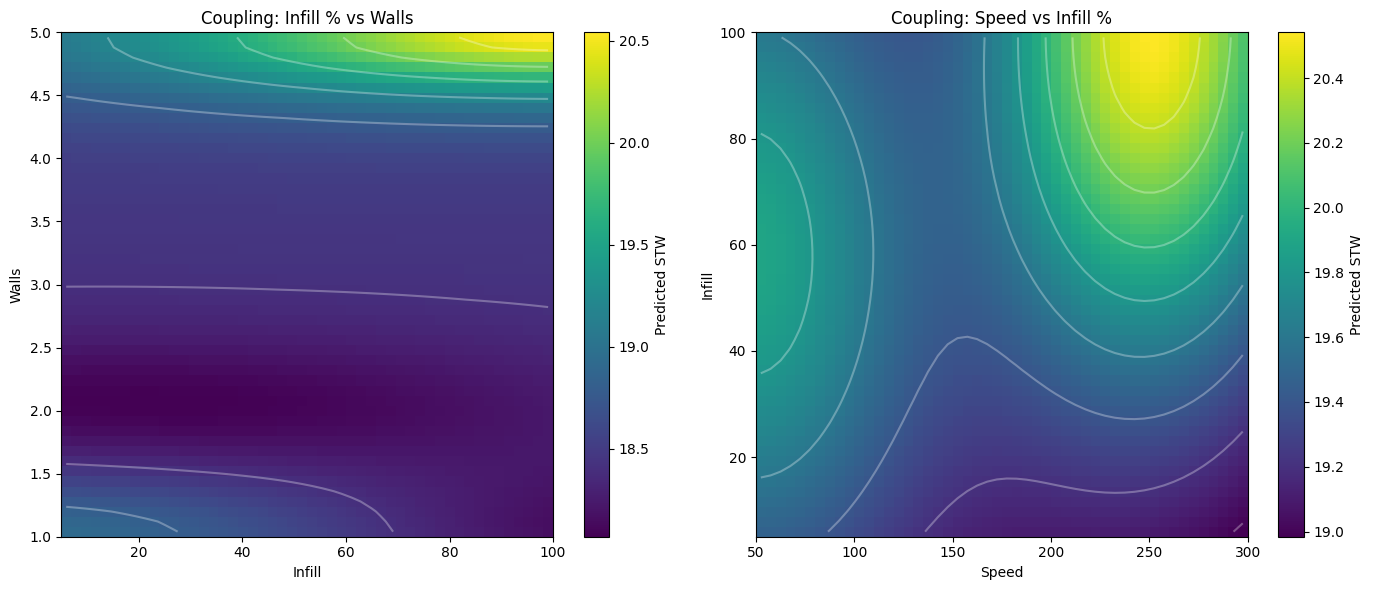

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# 1. LOAD & FILTER DATA
# ==========================================
CSV_FILE = "data.csv"
# (Or "data.csv" if you renamed it)

COL_MAP = {
    'infill': 'Infill percent',
    'layer': 'Layer Height(mm)',
    'walls': 'Wall Loops',
    'tops': 'Top Layers',
    'speed': 'Print speed settings',
    'target': 'Str/w (N/g)',
    'material': 'Material'
}

# Bounds (must match what we trained on)
BOUNDS = {
    'infill': (5, 100),
    'layer': (0.08, 0.32),
    'walls': (1, 5),
    'tops': (1, 6),
    'speed': (50, 300)
}
NOISE_VAR = 1.8e-5

# Load Data
df = pd.read_csv(CSV_FILE)

# *** CRITICAL STEP: Filter for Sunlu Only ***
# We drop the old Bambu points to prevent "Cluster Gravity"
df = df[df[COL_MAP['material']] != 'Bambu PLA'].copy()

# Extract Features (X) and Target (y)
X = df[[COL_MAP['infill'], COL_MAP['layer'], COL_MAP['walls'],
        COL_MAP['tops'], COL_MAP['speed']]].values
y = df[COL_MAP['target']].values.astype(float)

# ==========================================
# 2. TRAIN THE GP
# ==========================================
def normalize(X):
    X_n = np.copy(X)
    keys = list(BOUNDS.keys())
    for i, k in enumerate(keys):
        X_n[:,i] = (X[:,i] - BOUNDS[k][0]) / (BOUNDS[k][1] - BOUNDS[k][0])
    return X_n

X_norm = normalize(X)
y_log = np.log(y)
y_mean = np.mean(y_log)
y_centered = y_log - y_mean

# Robust Kernel (Clamped Length Scales)
kernel = ConstantKernel(1.0) * \
         Matern(length_scale=[0.5]*5, length_scale_bounds=(0.1, 10.0), nu=2.5) + \
         WhiteKernel(noise_level=NOISE_VAR, noise_level_bounds='fixed')

gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=25)
gp.fit(X_norm, y_centered)

# ==========================================
# 3. GENERATE HEATMAPS
# ==========================================
# We define a function to plot 2 variables while holding the others constant
# at the "Best Known Settings" (to show the most relevant slice).

best_idx = np.argmax(y)
center_norm = X_norm[best_idx] # The settings of your Champion Beam

# Create a 50x50 Grid
res = 50
grid_x = np.linspace(0, 1, res)
grid_y = np.linspace(0, 1, res)
X_grid, Y_grid = np.meshgrid(grid_x, grid_y)

def plot_interaction(var1_idx, var2_idx, ax, title):
    # 1. Create a matrix where EVERY row is the "Champion Beam"
    X_in = np.tile(center_norm, (res*res, 1))

    # 2. Overwrite the two columns we want to test
    X_in[:, var1_idx] = X_grid.ravel()
    X_in[:, var2_idx] = Y_grid.ravel()

    # 3. Ask GP to predict
    mu, _ = gp.predict(X_in, return_std=True)
    mu_real = np.exp(mu + y_mean).reshape(res, res)

    # 4. Plot
    var1_name = list(BOUNDS.keys())[var1_idx]
    var2_name = list(BOUNDS.keys())[var2_idx]
    extent = [BOUNDS[var1_name][0], BOUNDS[var1_name][1],
              BOUNDS[var2_name][0], BOUNDS[var2_name][1]]

    cp = ax.imshow(mu_real, origin='lower', extent=extent, aspect='auto', cmap='viridis')
    ax.set_xlabel(var1_name.capitalize())
    ax.set_ylabel(var2_name.capitalize())
    ax.set_title(title)
    ax.contour(mu_real, origin='lower', extent=extent, colors='white', alpha=0.3)
    return cp

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Infill vs Walls (Indices 0 and 2)
cp1 = plot_interaction(0, 2, axes[0], "Coupling: Infill % vs Walls")
fig.colorbar(cp1, ax=axes[0], label='Predicted STW')

# Plot 2: Speed vs Infill (Indices 4 and 0)
cp2 = plot_interaction(4, 0, axes[1], "Coupling: Speed vs Infill %")
fig.colorbar(cp2, ax=axes[1], label='Predicted STW')

plt.tight_layout()
plt.show()